# Using Seaborn and Matplotlib Together

For many plotting needs, the easiest process is to start out with a seaborn plot and subsequently edit this plot with matplotlib. This notebook walks through some examples where the seaborn-to-matplotlib pipeline is useful.

In [62]:
import matplotlib.pyplot as plt
import seaborn as sns

In [63]:
df = sns.load_dataset('taxis')
df.head()

,pickup,dropoff,passengers,distance,fare,tip,tolls,total,color,payment,pickup_zone,dropoff_zone,pickup_borough,dropoff_borough
0,2019-03-23 20:21:09,2019-03-23 20:27:24,1,1.60,7.0,2.15,0.0,12.95,yellow,credit card,Lenox Hill West,UN/Turtle Bay South,Manhattan,Manhattan
1,2019-03-04 16:11:55,2019-03-04 16:19:00,1,0.79,5.0,0.00,0.0,9.30,yellow,cash,Upper West Side South,Upper West Side South,Manhattan,Manhattan
2,2019-03-27 17:53:01,2019-03-27 18:00:25,1,1.37,7.5,2.36,0.0,14.16,yellow,credit card,Alphabet City,West Village,Manhattan,Manhattan
3,2019-03-10 01:23:59,2019-03-10 01:49:51,1,7.70,27.0,6.15,0.0,36.95,yellow,credit card,Hudson Sq,Yorkville West,Manhattan,Manhattan
4,2019-03-30 13:27:42,2019-03-30 13:37:14,3,2.16,9.0,1.10,0.0,13.40,yellow,credit card,Midtown East,Yorkville West,Manhattan,Manhattan


In [64]:
df['pickup'].head()

0   2019-03-23 20:21:09
1   2019-03-04 16:11:55
2   2019-03-27 17:53:01
3   2019-03-10 01:23:59
4   2019-03-30 13:27:42
Name: pickup, dtype: datetime64[ns]

In [65]:
df['pickup'][1].hour

16

In [66]:
df['pickup_time_of_day'] = [pickup.hour for pickup in df['pickup']]
df.head()

,pickup,dropoff,passengers,distance,fare,tip,tolls,total,color,payment,pickup_zone,dropoff_zone,pickup_borough,dropoff_borough,pickup_time_of_day
0,2019-03-23 20:21:09,2019-03-23 20:27:24,1,1.60,7.0,2.15,0.0,12.95,yellow,credit card,Lenox Hill West,UN/Turtle Bay South,Manhattan,Manhattan,20
1,2019-03-04 16:11:55,2019-03-04 16:19:00,1,0.79,5.0,0.00,0.0,9.30,yellow,cash,Upper West Side South,Upper West Side South,Manhattan,Manhattan,16
2,2019-03-27 17:53:01,2019-03-27 18:00:25,1,1.37,7.5,2.36,0.0,14.16,yellow,credit card,Alphabet City,West Village,Manhattan,Manhattan,17
3,2019-03-10 01:23:59,2019-03-10 01:49:51,1,7.70,27.0,6.15,0.0,36.95,yellow,credit card,Hudson Sq,Yorkville West,Manhattan,Manhattan,1
4,2019-03-30 13:27:42,2019-03-30 13:37:14,3,2.16,9.0,1.10,0.0,13.40,yellow,credit card,Midtown East,Yorkville West,Manhattan,Manhattan,13


`ax.twinx()`

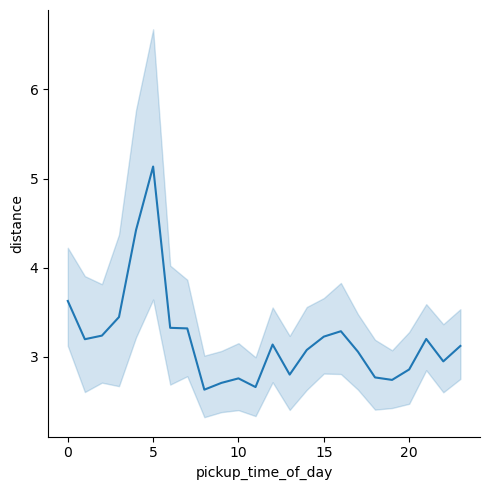

In [67]:
ax1 = sns.relplot(
    data=df, kind='line',
    x='pickup_time_of_day',
    y='distance',
)

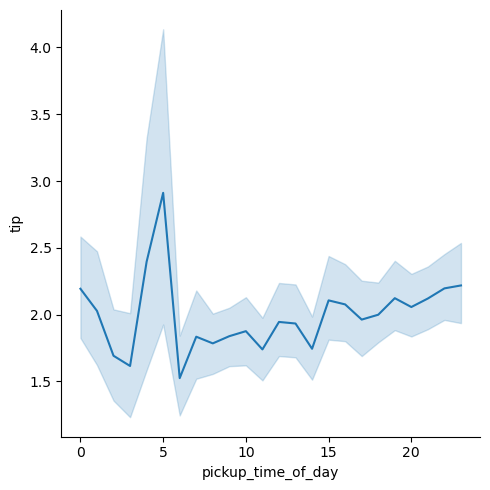

In [68]:
'''
ax1 = sns.relplot(
    data=df, kind='line',
    x='pickup_time_of_day',
    y='distance',
)
'''

ax2 = sns.relplot(
    data=df, kind='line',
    x='pickup_time_of_day',
    y='tip'
)

<Axes: xlabel='pickup_time_of_day', ylabel='tip'>

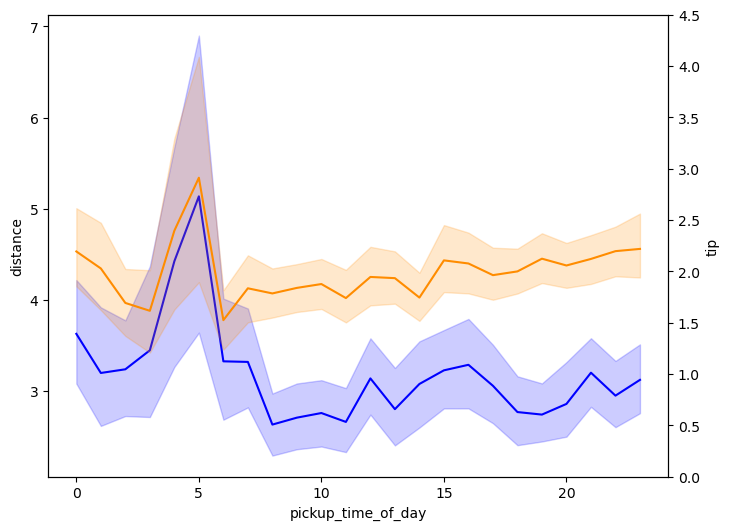

In [69]:
fig, ax1 = plt.subplots(figsize=(8, 6))

ax2 = ax1.twinx()
ax2.set_ylim(0, 4.5)

sns.lineplot(
    data=df, x='pickup_time_of_day', y='distance',
    ax=ax1, color='blue'
)

sns.lineplot(
    data=df, x='pickup_time_of_day', y='tip',
    ax=ax2, color='darkorange'
)

Text(0.5, 0, 'Pickup Time of Day (hr)')

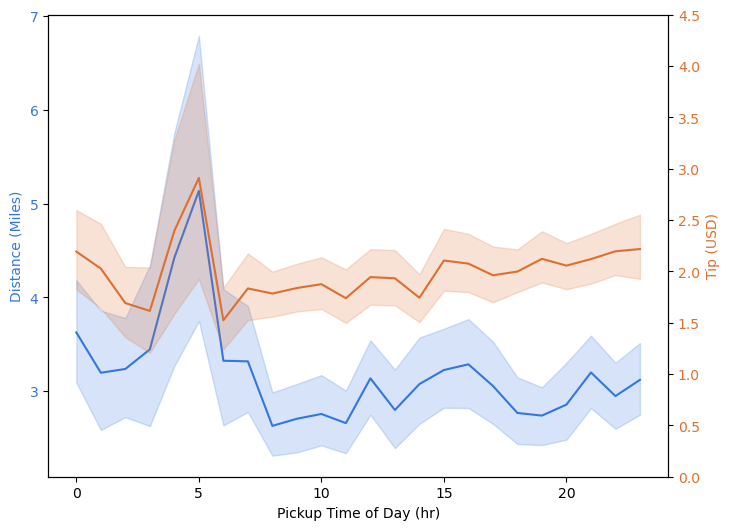

In [70]:
fig, ax1 = plt.subplots(figsize=(8, 6))

ax2 = ax1.twinx()
ax2.set_ylim(0, 4.5)

# You can specify custom colors using hexadecimal values:
col1 = "#3476DF"
col2 = "#DD6F2F"

sns.lineplot(
    data=df, x='pickup_time_of_day', y='distance',
    ax=ax1, color=col1
)

sns.lineplot(
    data=df, x='pickup_time_of_day', y='tip',
    ax=ax2, color=col2
)

ax1.set_ylabel('Distance (Miles)', color=col1)
ax2.set_ylabel('Tip (USD)', color=col2)
ax1.tick_params(axis='y', labelcolor=col1)
ax2.tick_params(axis='y', labelcolor=col2)

#ax2.set_xticklabels(['0:00', '5:00', '10:00', '15:00', '20:00'])

ax1.set_xlabel('Pickup Time of Day (hr)')
ax2.set_xlabel('Pickup Time of Day (hr)')

Note: this dataset was trimmed to include only normalized molar concentrations of reacting species at an inital temperature and pressure of 873K and 399kPa, respectively.

In [71]:
import pandas as pd

df = pd.read_csv('methane_pyrolysis_873K_399kPa_normalized_Tatum_J_et_al.csv')
df.head()

,reaction_time,temperature,pressure,methane,ethane,ethylene,propane,acetylene,benzene,helium,hydrogen
0,15,895,435,81.09,0.0070,0.00029,NaN,NaN,NaN,NaN,16.79
1,15,894,424,88.18,0.0461,0.00210,NaN,NaN,NaN,NaN,9.92
2,15,900,413,95.09,0.0060,NaN,NaN,NaN,NaN,0.05,4.65
3,15,896,440,82.74,0.0053,0.00026,NaN,NaN,NaN,0.04,15.56
4,15,899,413,95.20,0.1767,0.07819,0.00351,NaN,NaN,NaN,3.28


Text(0.5, 0, 'Reaction Time (s)')

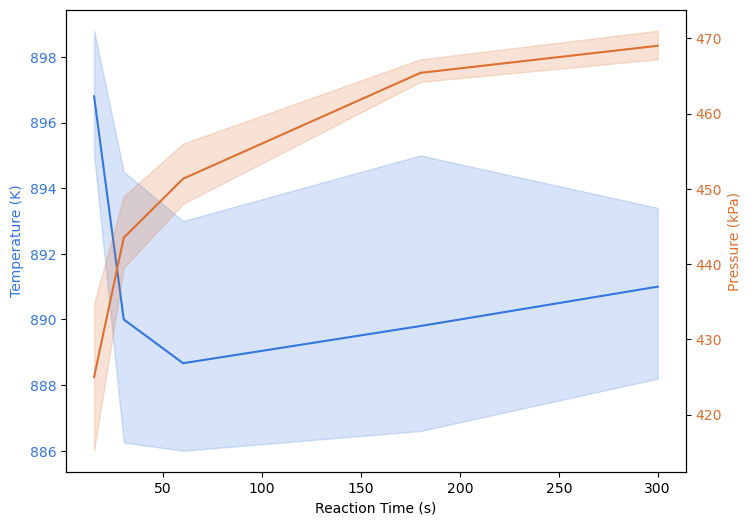

In [72]:
fig, ax1 = plt.subplots(figsize=(8, 6))

ax2 = ax1.twinx()

col1 = "#3476DF"
col2 = "#DD6F2F"

sns.lineplot(
    data=df, x='reaction_time', y='temperature',
    ax=ax1, color=col1
)

sns.lineplot(
    data=df, x='reaction_time', y='pressure',
    ax=ax2, color=col2
)

ax1.set_ylabel('Temperature (K)', color=col1)
ax2.set_ylabel('Pressure (kPa)', color=col2)
ax1.tick_params(axis='y', labelcolor=col1)
ax2.tick_params(axis='y', labelcolor=col2)

ax1.set_xlabel('Reaction Time (s)')
ax2.set_xlabel('Reaction Time (s)')


`plt.axvspan()`

### Resources and References:

- [ax.twinx()](https://python-graph-gallery.com/line-chart-dual-y-axis-with-matplotlib/)
- [List of seaborn built-in datasets](https://www.kaggle.com/datasets/abdoomoh/all-seaborn-built-in-datasets)
- [Datavis caveats](https://www.data-to-viz.com/caveats.html)
- Tatum, James; Punia, Ambuj; Kostiuk, Larry; Secanell, Marc; Olfert, Jason (2022), *“Methane pyrolysis products in a constant-volume reactor as a function of time”*, Mendeley Data, V1, doi: 10.17632/3d4yftz66n.1
    - [Open Access Article](https://www.sciencedirect.com/science/article/pii/S2352340923000719)
    - [Open Access Dataset](https://data.mendeley.com/datasets/3d4yftz66n/1)
    - [CC BY 4.0 License](https://creativecommons.org/licenses/by/4.0/)